In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras import layers, models

In [ ]:
(x_train, y_train), _ = mnist.load_data()
x = x_train[:1000]
y = y_train[:1000]

x_rgb = np.stack([x]*3, axis=-1)
x_rgb_resized = tf.image.resize(x_rgb, (224, 224)).numpy()
x_preprocessed = preprocess_input(x_rgb_resized)
y_cat = to_categorical(y, num_classes=10)
x_input = preprocess_input(x_rgb_resized)

In [ ]:
def reduce_and_plot(features, method, title, labels):
    if method == 'pca':
        reducer = PCA(n_components=2)
    elif method == 'tsne':
        reducer = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
    elif method == 'umap':
        reducer = umap.UMAP(n_components=2, random_state=42)

    reduced = reducer.fit_transform(features)
    plt.figure(figsize=(6,5))
    plt.scatter(reduced[:,0], reduced[:,1], c=labels, cmap='tab10', s=10)
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 196ms/step


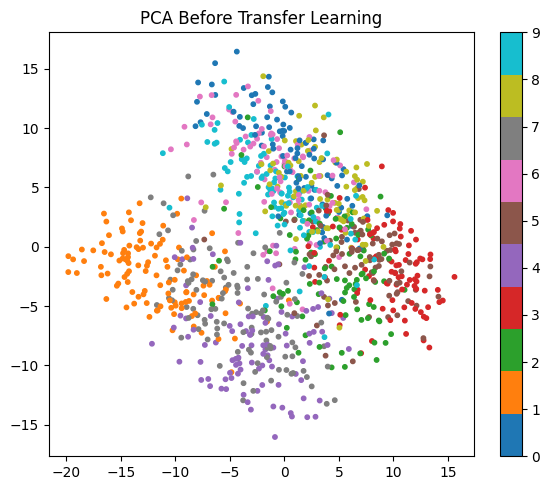

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


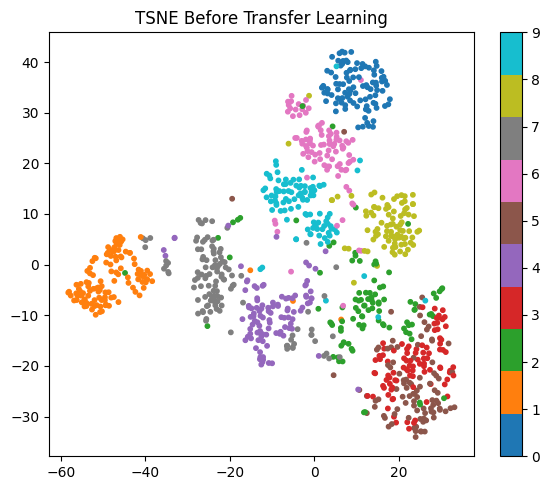

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


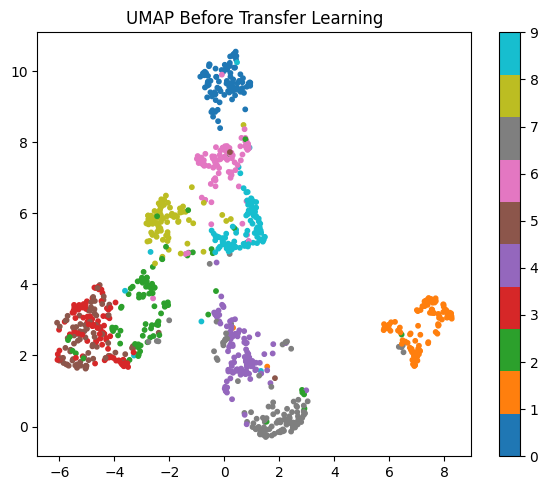

In [ ]:
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
features = base_model.predict(x_input, verbose=1)
for method in ['pca', 'tsne', 'umap']:
    reduce_and_plot(features, method, f"{method.upper()} Before Transfer Learning", y)

Transfer Learning


Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 33s 635ms/step - accuracy: 0.5820 - loss: 1.4429
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - accuracy: 0.9142 - loss: 0.3737
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step - accuracy: 0.9501 - loss: 0.1902
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 161ms/step - accuracy: 0.9750 - loss: 0.1037
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 161ms/step - accuracy: 0.9975 - loss: 0.0495
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - accuracy: 0.9933 - loss: 0.0323
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 165ms/step - accuracy: 0.9985 - loss: 0.0205
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step - accuracy: 1.0000 - loss: 0.0167
Epoch 9/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step - accuracy: 1.0000 - loss: 0.0091
Epoch 10/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 163ms/step - accuracy: 1.0000 - loss: 0.0089
Epoch 11/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 171ms/step - accuracy: 0.9984 - loss: 0.0070
Epoch 12/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/ste

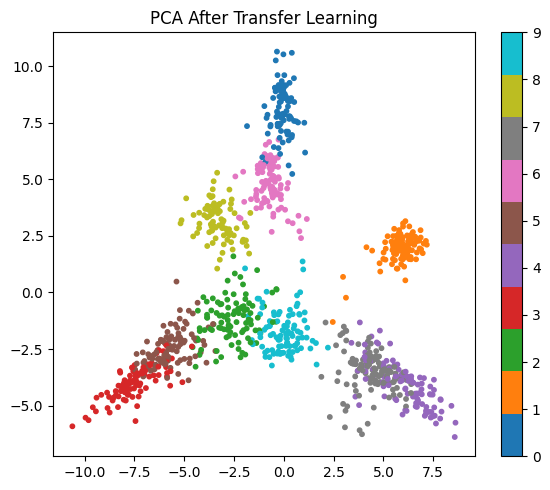

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


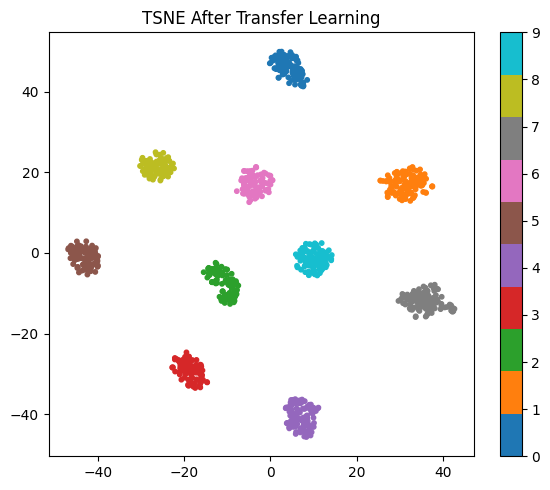

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


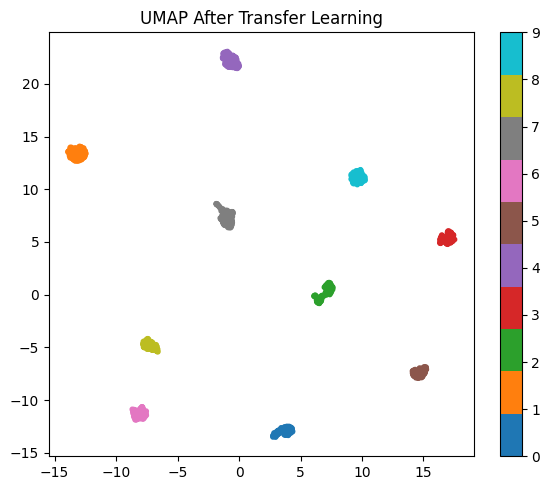

In [ ]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_preprocessed, y_cat, epochs=20, batch_size=64, verbose=1)
feature_model = tf.keras.Model(inputs=model.input, outputs=model.layers[-2].output)

features_after = feature_model.predict(x_preprocessed, verbose=1)
for method in ['pca', 'tsne', 'umap']:
    reduce_and_plot(features_after, method, f"{method.upper()} After Transfer Learning", y)